In [1]:
# Imports, DB connection, load purchase propensity features

import os
import pandas as pd
from sqlalchemy import create_engine
from dotenv import load_dotenv

load_dotenv()

engine = create_engine(
    f"postgresql+psycopg2://{os.getenv('DB_USER')}:{os.getenv('DB_PASSWORD')}"
    f"@{os.getenv('DB_HOST')}:{os.getenv('DB_PORT')}/{os.getenv('DB_NAME')}"
)

query = """
SELECT
    c.customer_id,
    c.acquisition_channel,
    c.country,
    c.customer_type,
    EXTRACT(YEAR FROM AGE(CURRENT_DATE, c.signup_date)) * 12 +
    EXTRACT(MONTH FROM AGE(CURRENT_DATE, c.signup_date)) AS account_age_months,
    COALESCE(browse.page_views, 0) AS page_views,
    COALESCE(browse.view_item_events, 0) AS view_item_events,
    COALESCE(browse.distinct_sessions, 0) AS distinct_sessions,
    COALESCE(browse.mobile_session_pct, 0) AS mobile_session_pct,
    COALESCE(crm.total_sent, 0) AS crm_emails_sent,
    COALESCE(crm.total_opened, 0) AS crm_emails_opened,
    COALESCE(crm.total_clicked, 0) AS crm_emails_clicked,
    CASE WHEN o.customer_id IS NOT NULL THEN 1 ELSE 0 END AS purchased
FROM customers c
LEFT JOIN (
    SELECT customer_id,
        COUNT(*) FILTER (WHERE event_name = 'page_view') AS page_views,
        COUNT(*) FILTER (WHERE event_name = 'view_item') AS view_item_events,
        COUNT(DISTINCT session_id) AS distinct_sessions,
        ROUND(100.0 * COUNT(*) FILTER (WHERE device_category = 'mobile') / COUNT(*), 1) AS mobile_session_pct
    FROM ga4_events
    WHERE event_name IN ('page_view', 'view_item')
    GROUP BY customer_id
) browse ON c.customer_id = browse.customer_id
LEFT JOIN (
    SELECT customer_id, COUNT(*) AS total_sent,
        SUM(opened::int) AS total_opened, SUM(clicked::int) AS total_clicked
    FROM crm_engagement
    GROUP BY customer_id
) crm ON c.customer_id = crm.customer_id
LEFT JOIN (
    SELECT DISTINCT customer_id FROM orders WHERE order_status = 'completed'
) o ON c.customer_id = o.customer_id;
"""

purchase_features = pd.read_sql(query, engine)
print(f"Loaded {len(purchase_features)} rows.")
print(f"Purchase rate: {purchase_features['purchased'].mean()*100:.1f}%")
purchase_features.head()

Loaded 20000 rows.
Purchase rate: 22.2%


,customer_id,acquisition_channel,country,customer_type,account_age_months,page_views,view_item_events,distinct_sessions,mobile_session_pct,crm_emails_sent,crm_emails_opened,crm_emails_clicked,purchased
0,1,Google,United Kingdom,saas,5.0,2,1,2,0.0,6,3,1,0
1,2,Organic,Nigeria,both,13.0,11,5,11,43.8,12,6,0,0
2,3,Google,Canada,ecommerce,20.0,3,3,3,66.7,14,4,0,0
3,4,Organic,Germany,saas,6.0,2,2,2,50.0,12,6,2,0
4,5,Google,United States,ecommerce,14.0,5,2,5,28.6,12,1,1,1


In [2]:
# One-hot encode categorical columns, split train/test

from sklearn.model_selection import train_test_split

# Three categorical columns this time (vs. just plan_name for churn)
purchase_features_encoded = pd.get_dummies(
    purchase_features, 
    columns=['acquisition_channel', 'country', 'customer_type'], 
    drop_first=True
)

feature_columns = [col for col in purchase_features_encoded.columns if col not in ['customer_id', 'purchased']]
X = purchase_features_encoded[feature_columns]
y = purchase_features_encoded['purchased']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Training set: {len(X_train)} rows, purchase rate: {y_train.mean()*100:.1f}%")
print(f"Test set: {len(X_test)} rows, purchase rate: {y_test.mean()*100:.1f}%")
print(f"\nTotal features: {len(feature_columns)}")

Training set: 16000 rows, purchase rate: 22.2%
Test set: 4000 rows, purchase rate: 22.2%

Total features: 20


In [3]:
# Training baseline vs. class-weighted logistic regression,
# compare directly (I already know from churn modeling to expect
# a recall problem on the minority class without weighting).

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report

purchase_model_baseline = LogisticRegression(max_iter=1000)
purchase_model_baseline.fit(X_train, y_train)
baseline_predictions = purchase_model_baseline.predict(X_test)

purchase_model_balanced = LogisticRegression(max_iter=1000, class_weight='balanced')
purchase_model_balanced.fit(X_train, y_train)
balanced_predictions = purchase_model_balanced.predict(X_test)

print("=== Baseline (no weighting) ===")
print(classification_report(y_test, baseline_predictions, target_names=['No Purchase', 'Purchased']))

print("\n=== Balanced (class_weight='balanced') ===")
print(classification_report(y_test, balanced_predictions, target_names=['No Purchase', 'Purchased']))

=== Baseline (no weighting) ===
              precision    recall  f1-score   support

 No Purchase       0.80      0.96      0.87      3113
   Purchased       0.51      0.16      0.25       887

    accuracy                           0.78      4000
   macro avg       0.66      0.56      0.56      4000
weighted avg       0.74      0.78      0.73      4000


=== Balanced (class_weight='balanced') ===
              precision    recall  f1-score   support

 No Purchase       0.88      0.74      0.80      3113
   Purchased       0.41      0.64      0.50       887

    accuracy                           0.72      4000
   macro avg       0.64      0.69      0.65      4000
weighted avg       0.77      0.72      0.73      4000



- **Baseline**: recall on "Purchased" is only **0.16**, misses the vast majority of actual buyers
- **Balanced**: recall jumps to **0.64**, catches roughly 4x more real buyers, at the cost of precision (0.41) and overall accuracy (72% vs 78%)

**Which one's right for this use case?** Think about the real business action this model would drive: if marketing uses this to decide who gets a "we think you're close to buying" nudge (a discount code, a retargeting ad, an email), the cost of a false positive (nudging someone who wasn't going to buy anyway) is low — a bit of wasted ad spend or an email someone ignores. The cost of a false negative (missing someone who *would* have bought, and never nudging them) is a lost sale. That asymmetry favors **recall**, same logic as churn, so **balanced** is the right choice here.

In [4]:
# Interpreting which features drive purchase propensity

purchase_feature_importance = pd.Series(
    purchase_model_balanced.coef_[0], index=feature_columns
).sort_values(ascending=False)

print("Feature impact on purchase likelihood (positive = increases likelihood):")
print(purchase_feature_importance)

Feature impact on purchase likelihood (positive = increases likelihood):
view_item_events                0.460499
acquisition_channel_Google      0.118564
acquisition_channel_Meta        0.112721
acquisition_channel_Organic     0.105381
country_United Kingdom          0.097371
acquisition_channel_Referral    0.057910
country_United States           0.057705
crm_emails_opened               0.017076
acquisition_channel_Email       0.004172
account_age_months              0.000810
mobile_session_pct              0.000534
country_Germany                -0.002872
crm_emails_sent                -0.004745
page_views                     -0.010335
distinct_sessions              -0.010335
country_India                  -0.041757
crm_emails_clicked             -0.049321
customer_type_saas             -0.059592
country_Nigeria                -0.091001
customer_type_ecommerce        -0.120117
dtype: float64



- **`view_item_events` (+0.46)** is by far the strongest signal, and genuinely a good one: someone who views more product pages is showing real purchase intent, without me touching add_to_cart/checkout (no leakage).

- **Acquisition channels (Google/Meta/Organic/Referral, all modestly positive)** - plausible: paid/organic-driven traffic tends to show slightly higher purchase likelihood. Modest, believable effects.

**Worth flagging before trusting it - `customer_type`:**

- **`customer_type_ecommerce` (−0.12)** and **`customer_type_saas` (−0.06)** are both notably negative relative to the baseline category (`both`, since that's what got dropped). At face value this reads as "ecommerce-only and SaaS-only customers are less likely to purchase than customers who do both", which sounds almost tautological rather than insightful (of course "both" type customers show higher ecommerce purchase rates, if that label was partly assigned based on their behavior).

There is a possibility there is another **circular/proxy variable**  where the label itself was influenced by whether they purchased, rather than being an independent, predictive signal and that would make it look artificially predictive without being a real, actionable insight.

I'll run permutation importance for genuine prediction

In [5]:
# Permutation importance to validate which features are genuinely
# predictive vs. which just look predictive from raw coefficients
# (same thing I did for the churn model).

from sklearn.inspection import permutation_importance

permutation_results_purchase = permutation_importance(
    purchase_model_balanced, X_test, y_test,
    n_repeats=10,
    random_state=42,
    scoring='recall'
)

permutation_importance_purchase = pd.Series(
    permutation_results_purchase.importances_mean, index=feature_columns
).sort_values(ascending=False)

print("Permutation importance (drop in recall when feature is shuffled):")
print(permutation_importance_purchase)

Permutation importance (drop in recall when feature is shuffled):
view_item_events                0.306877
customer_type_ecommerce         0.011499
acquisition_channel_Meta        0.009696
crm_emails_opened               0.009132
country_United States           0.007328
acquisition_channel_Organic     0.005862
country_Nigeria                 0.005073
country_United Kingdom          0.004735
customer_type_saas              0.004510
page_views                      0.004397
distinct_sessions               0.004397
mobile_session_pct              0.002255
account_age_months              0.001466
crm_emails_clicked              0.000676
country_India                   0.000225
acquisition_channel_Email       0.000000
country_Germany                 0.000000
acquisition_channel_Referral   -0.000225
crm_emails_sent                -0.001015
acquisition_channel_Google     -0.001917
dtype: float64


**`view_item_events`: 0.307** - completely dominant, by an enormous margin. This confirms it's a real, robust signal, not a coefficient artifact, shuffling it alone accounts for almost all of the model's predictive power.

**`customer_type_ecommerce`: 0.011** - it's **tiny** compared to `view_item_events`, about 3.5% as impactful. So the coefficient wasn't *wrong*, exactly, but it was misleadingly prominent-looking in the raw coefficient list relative to its true, minor contribution. 

**Everything else** - acquisition channel, country, CRM engagement, account age, all cluster near zero, some even slightly negative (meaning the model does marginally *better* without them, i.e. pure noise).

## My final conclusion

> **Browsing intent (specifically, how many product pages someone views) is overwhelmingly the strongest predictor of whether a customer will purchase. Nothing else tested meaningfully improves the prediction once view_item_events is accounted for.**

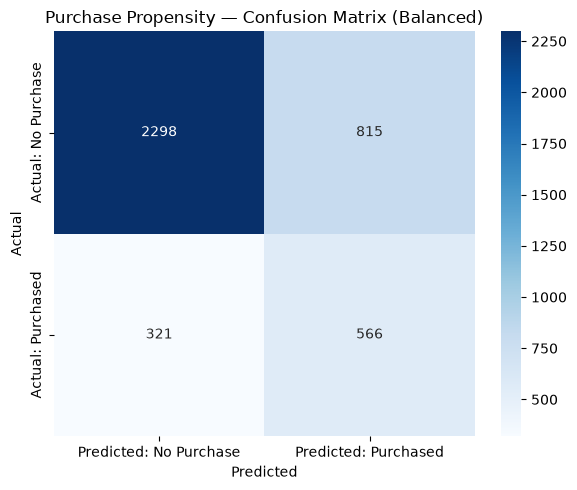

In [6]:
# Confusion matrix heatmap for the balanced purchase propensity model

import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

confusion_matrix_purchase = confusion_matrix(y_test, balanced_predictions)

plt.figure(figsize=(6, 5))
sns.heatmap(
    confusion_matrix_purchase,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['Predicted: No Purchase', 'Predicted: Purchased'],
    yticklabels=['Actual: No Purchase', 'Actual: Purchased']
)
plt.title('Purchase Propensity — Confusion Matrix (Balanced)')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.show()

566 true purchasers correctly caught vs. 321 missed, matching the 0.64 recall I calculated earlier (566/887 ≈ 0.64). Solid, matches my expectations.

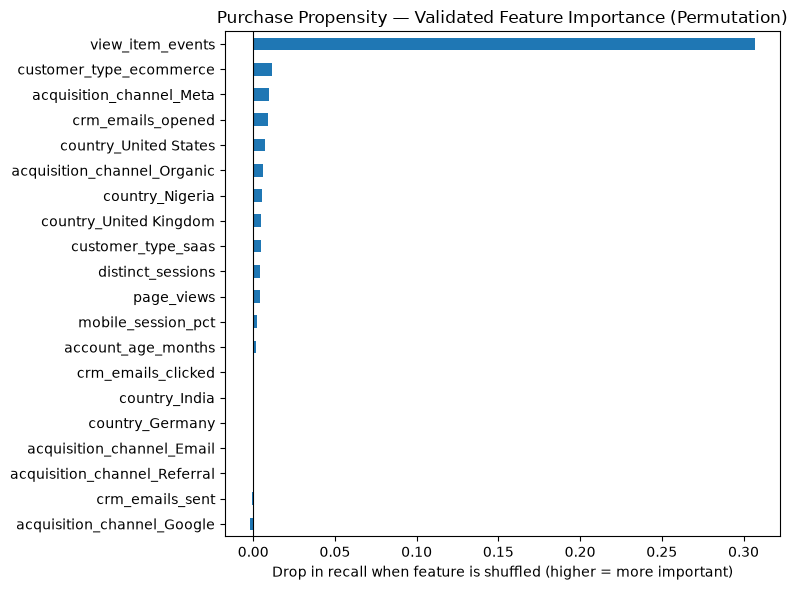

In [7]:
# Visualizing validated feature importance (permutation-based)

plt.figure(figsize=(8, 6))
permutation_importance_purchase.sort_values().plot(kind='barh', color='#1f77b4')
plt.title('Purchase Propensity — Validated Feature Importance (Permutation)')
plt.xlabel('Drop in recall when feature is shuffled (higher = more important)')
plt.axvline(x=0, color='black', linewidth=0.8)
plt.tight_layout()
plt.show()

In [8]:
import joblib

joblib.dump(purchase_model_balanced, 'purchase_model.pkl')
joblib.dump(feature_columns, 'purchase_model_features.pkl')

['purchase_model_features.pkl']